# What Actually Drives Draft Position? Combining College Production & Athletic Testing

## Executive Summary
In Notebook 02, we discovered that college yards per game alone is a weak predictor of draft position. The 50-70 YPG baseline was consistent across almost every round, suggesting that **something else** separates first-rounders from Day 3 picks.

This notebook tests the hypothesis that **athletic testing (40-yard dash) combined with college production metrics** tells a more complete story. By blending these factors, we can identify which variables truly correlate with draft capital.

## Key Questions
1. Does 40 time matter more than college production?
2. Which college metric (YPG, YPC, or peak TDs) best predicts draft position?
3. Do players from Power 5 conferences get a draft boost regardless of production?
4. Can we identify the "perfect" prospect profile vs. the "overachiever" profile?

## Methodology
- **Data Sources:** College receiving stats, NFL Combine results, draft position (2017-2025)
- **Key Metrics:** 
  - College YPG (career average)
  - Yards per catch (efficiency)
  - Peak TD season (upside)
  - 40-yard dash (athletic ceiling)
  - Conference tier (competition level)
- **Filter:** Only players with verified 40 times (ensures apples-to-apples comparison)

In [6]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('nfl_analytics.db')

# combines college production, combine stats, and draft position
query = """
WITH player_data AS (
    SELECT 
        c.Player,
        c.Conf,
        -- college production
        AVG(c.RecYperG) as college_ypg,
        AVG(c.YperR) as yards_per_catch,
        MAX(c.RecTD) as peak_td,
        -- combine athletic testing
        com.`40yd` as forty_time,
        com.`3cone` as cone_time,
        com.Vertical,
        com.`Broad Jump` as broad_jump,
        -- draft information
        d.Player AS Pick,
        d.Round,
        d.Year as draft_year,
        -- conference tier
        CASE 
            WHEN c.Conf IN ('SEC', 'Big Ten') THEN 'SEC, BIG 10'
            WHEN c.Conf IN ('ACC', 'Big 12', 'Pac-12') THEN 'ACC, BIG 12, PAC 12'
            ELSE 'Other'
        END as conference_tier
    FROM college c
    LEFT JOIN draft_picks d ON d.Name = c.Player
    LEFT JOIN combine com ON com.Player = c.Player
    WHERE d.Year BETWEEN 2017 AND 2025
        AND com.`40yd` IS NOT NULL  -- Only players with 40 time
        AND com.`40yd` > 0
    GROUP BY c.Player
)
SELECT * FROM player_data
ORDER BY Pick;
"""


# execute and display
player_data = pd.read_sql_query(query, conn)

print("WR COLLEGE STATS, COMBINE STATS, AND SELECTION DATA (2017-2025)")
print("=" * 100)
print(player_data.head(10))


conn.close()

WR COLLEGE STATS, COMBINE STATS, AND SELECTION DATA (2017-2025)
           Player     Conf  college_ypg  yards_per_catch  peak_td  forty_time  \
0   Ja'Marr Chase      SEC   127.100000        21.200000       20        4.34   
1     Rome Odunze   Pac-12    83.600000        14.400000       13        4.45   
2  Garrett Wilson  Big Ten    72.500000        15.433333       12        4.38   
3     Chris Olave  Big Ten    80.900000        15.433333       13        4.39   
4     Jerry Jeudy      SEC    88.600000        17.200000       14        4.45   
5    Jahan Dotson  Big Ten    78.066667        16.033333       12        4.43   
6     CeeDee Lamb   Big 12    80.800000        18.900000       14        4.50   
7   Treylon Burks      SEC    75.433333        16.400000       11        4.55   
8  Kadarius Toney      SEC    89.500000        14.100000       10        4.39   
9    Jalen Reagor   Big 12    57.866667        15.466667        9        4.47   

   cone_time  Vertical  broad_jump  Pick  Ro

## Exploratory Data Analysis

Before diving into correlations, let's understand our data distributions. This helps us spot outliers and validate our metrics.

In [7]:
# summary statistics
print("SUMMARY STATISTICS")
print("=" * 60)
print(player_data[['college_ypg', 'yards_per_catch', 'peak_td', 'forty_time', 'Pick']].describe().round(2))

# check for correlations
print("\nCORRELATION WITH DRAFT POSITION")
print("=" * 60)
correlations = player_data[['college_ypg', 'yards_per_catch', 'peak_td', 'forty_time', 'Pick']].corr()['Pick'].sort_values(ascending=False)
print(correlations.to_string())

# distribution of 40 times by round
print("\nAVERAGE 40 TIME BY DRAFT ROUND")
print("=" * 60)
round_40 = player_data.groupby('Round')['forty_time'].agg(['mean', 'min', 'max']).round(2)
print(round_40.to_string())

SUMMARY STATISTICS
       college_ypg  yards_per_catch  peak_td  forty_time    Pick
count       167.00           167.00   167.00      167.00  167.00
mean         69.94            15.23     8.97        4.46  121.56
std          19.91             2.37     3.25        0.09   73.70
min          32.95            10.55     1.00        4.21    5.00
25%          54.72            13.35     7.00        4.40   56.00
50%          68.15            15.17     9.00        4.46  110.00
75%          83.25            16.64    11.00        4.51  185.00
max         140.40            21.20    20.00        4.73  258.00

CORRELATION WITH DRAFT POSITION
Pick               1.000000
forty_time         0.379406
yards_per_catch   -0.131656
college_ypg       -0.258702
peak_td           -0.362642

AVERAGE 40 TIME BY DRAFT ROUND
       mean   min   max
Round                  
1      4.42  4.21  4.55
2      4.42  4.28  4.61
3      4.45  4.27  4.65
4      4.45  4.34  4.60
5      4.48  4.37  4.73
6      4.49  4.33  4.61

### Key Takeaways from Exploratory Analysis

Before visualizing the data, let's understand what the numbers are telling us about what actually drives draft position:

**1. 40-yard dash time has the strongest correlation with draft position (r = 0.38)**
This is the biggest surprise. Athletic testing—specifically straight-line speed—correlates more strongly with where a receiver gets drafted than any college production metric we measured. The positive correlation means: **slower 40 times = later picks**.

**2. Peak touchdowns (r = -0.36) matters more than yards per game (r = -0.26)**
NFL teams appear to value a receiver's ability to find the end zone over pure volume stats. A single dominant TD season might signal more about a player's upside than consistent yardage accumulation.

**3. Yards per catch (r = -0.13) is essentially uncorrelated with draft position**
Efficiency metrics don't predict draft stock. Whether a receiver averages 12 yards per catch or 20, it barely moves the needle on draft day.

**4. The 40-time progression by round tells the same story**
| Round | Avg 40 Time |
|-------|-------------|
| 1 | 4.42 |
| 2 | 4.42 |
| 3 | 4.45 |
| 4 | 4.45 |
| 5 | 4.48 |
| 6 | 4.49 |
| 7 | 4.52 |

The trend is clear: **earlier rounds draft faster players**. Even Round 4's slight dip (4.45) is interesting—possibly the "value round" for fast players who fell due to other factors.

**The Big Picture:** These correlations confirm what we suspected in Notebook 2—college production alone doesn't drive draft position. Athletic testing (specifically speed) plays a major role. Now let's visualize this relationship to see the pattern with our own eyes.

### Scatter Plot

Now it's time to visualize how these three factors—speed, college production, and conference pedigree—interact to determine draft position. For this plot:

- **X-Axis:** 40-yard dash time (faster times on the left)
- **Y-Axis:** Draft position (earlier picks at the top)
- **Point Size:** College yards per game (larger circles = more productive)
- **Point Color:** Conference tier

#### Legend

| X-Axis | Y-Axis | Point Size | Point Color |
|:---|:---|:---|:---|
| 40-Yard Dash | Draft Position | College YPG<br>• BIG = 90+ YPG<br>• SMALL = 0-50 YPG | Conference<br>• RED = SEC, Big Ten<br>• BLUE = ACC, Big 12, Pac-12<br>• GREEN = Other |

#### What This Visualization Shows

Based on our correlation analysis, we expect to see:

- **The fastest players clustered near the TOP of the plot**—40 time should be the clearest differentiator between early and late rounds
- **Point size varying even among top picks**—some first-rounders were elite college producers, others were drafted primarily on athletic upside
- **Red dots (SEC/Big Ten) overrepresented among early picks**—conference pedigree providing a boost even when production or speed metrics are comparable

If we see this pattern, it confirms: **NFL teams prioritize speed first, then use college production and conference pedigree as tie-breakers.**

CREATING SCATTER PLOT: COLLEGE PRODUCTION vs DRAFT POSITION
Total players with data: 167
Pick range: 5 to 258



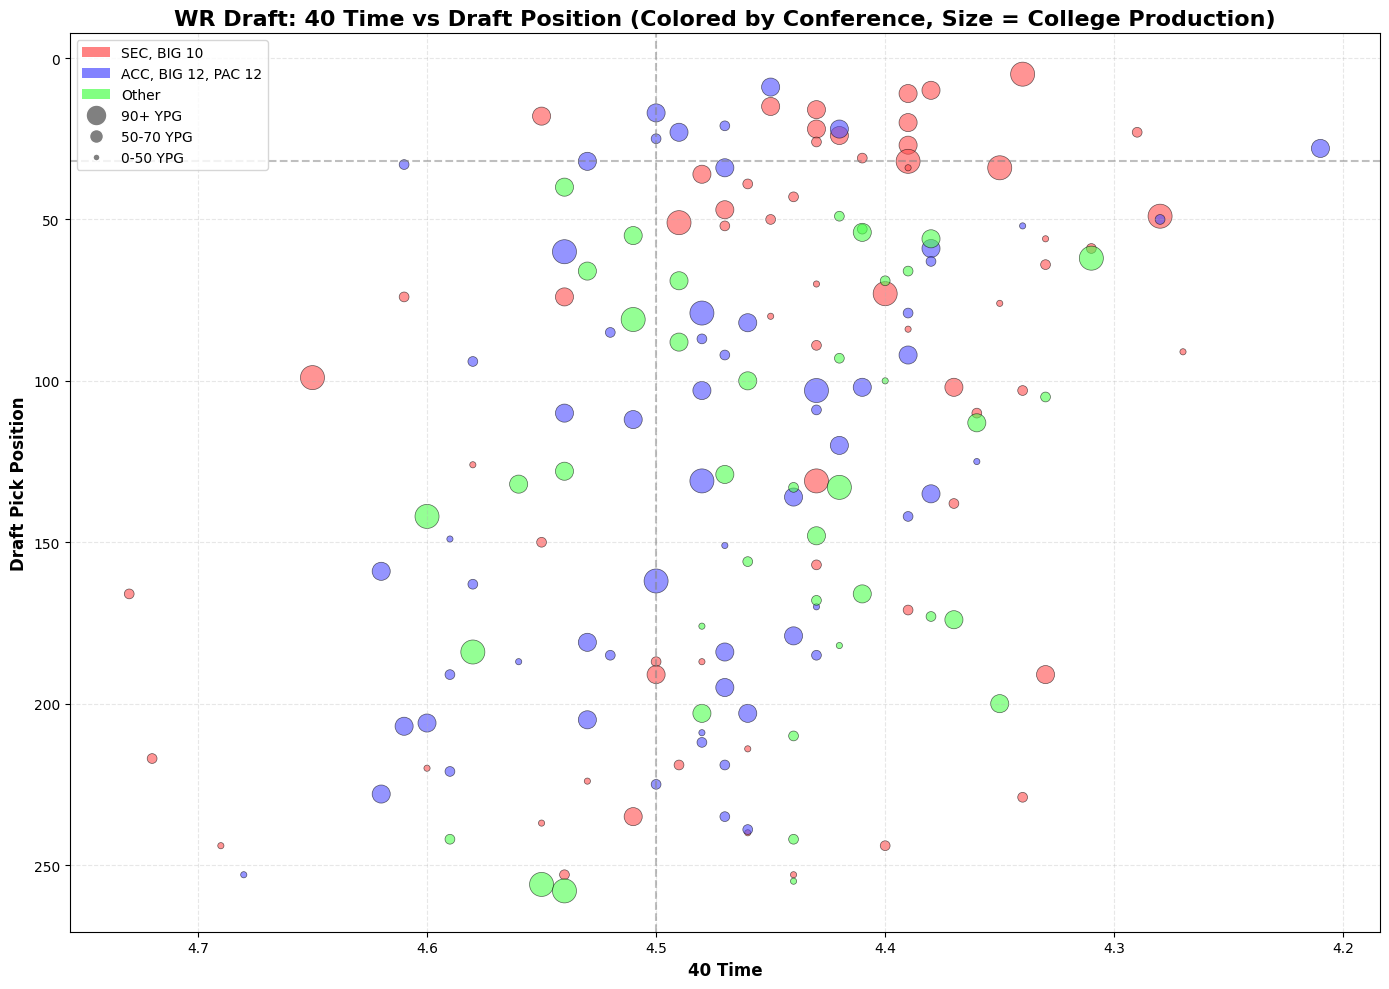


SUMMARY BY CONFERENCE TIER:
                     Count  Avg YPG  Avg 40 Time  Avg Pick
conference_tier                                           
ACC, BIG 12, PAC 12     62    71.05         4.48    128.21
Other                   41    73.99         4.45    134.37
SEC, BIG 10             64    66.27         4.45    106.92

Visualization saved as 'wr_draft_scatter_by_pick.png'


In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def get_marker_size(YPG):
    # BASED ON ROUNDS LAST YEAR
    if YPG >= 90:
        return 300  # Elite College Production: huge
    elif YPG >= 70:
        return 170  # : big
    elif YPG >= 50:
        return 50  # Round 2: medium-large
    else:
        return 20   # Round 7: tiny


print("CREATING SCATTER PLOT: COLLEGE PRODUCTION vs DRAFT POSITION")
print("=" * 60)

# first, let's check what's in player_data
print(f"Total players with data: {len(player_data)}")
print(f"Pick range: {player_data['Pick'].min()} to {player_data['Pick'].max()}")
print("\n" + "=" * 60)

# set up the plot
fig, ax = plt.subplots(figsize=(14, 10))

# define colors for conference tiers
conference_colors = {
    'SEC, BIG 10': '#FF4D4D',         # Red
    'ACC, BIG 12, PAC 12': '#4D4DFF', # Blue
    'Other': '#4DFF4D'                # Green
}

# define marker sizes based on 40 time (lower 40 time = bigger marker)
#max_pick = player_data['forty_time'].max()
player_data['marker_size'] = player_data['college_ypg'].apply(get_marker_size)
# create scatter plot for each conference tier
for tier, color in conference_colors.items():
    tier_data = player_data[player_data['conference_tier'] == tier]
    
    if len(tier_data) > 0:
        scatter = ax.scatter(
            tier_data['forty_time'], 
            tier_data['Pick'],
            s=tier_data['marker_size'],  # Size by pick number
            c=color,
            alpha=0.6,
            edgecolors='black',
            linewidth=0.5,
            label=f"{tier} ({len(tier_data)} players)"
        )

# add labels for top 10 picks
#top_picks = player_data[player_data['Pick'] <= 10]
#for _, player in top_picks.iterrows():
#    ax.annotate(
#        f"{player['Player']} (#{player['Pick']})",
#        (player['college_ypg'], player['forty_time']),
#        xytext=(5, 5),
#        textcoords='offset points',
#        fontsize=9,
#        fontweight='bold',
#        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7)
#    )

# add a colorbar to explain marker sizes
# create a legend for pick ranges
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor='#FF4D4D', alpha=0.7, label='SEC, BIG 10'),
    Patch(facecolor='#4D4DFF', alpha=0.7, label='ACC, BIG 12, PAC 12'),
    Patch(facecolor='#4DFF4D', alpha=0.7, label='Other'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=15, label='90+ YPG'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='50-70 YPG'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=5, label='0-50 YPG')
]

# customize the chart
ax.set_xlabel('40 Time', fontsize=12, fontweight='bold')
ax.set_ylabel('Draft Pick Position', fontsize=12, fontweight='bold')
ax.set_title('WR Draft: 40 Time vs Draft Position (Colored by Conference, Size = College Production)', 
             fontsize=16, fontweight='bold')

# invert y-axis (lower 40 time is better)
ax.invert_yaxis()
ax.invert_xaxis()

# add grid
ax.grid(True, alpha=0.3, linestyle='--')

# add legend
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

# add some reference lines (optional)
ax.axhline(y=32, color='gray', linestyle='--', alpha=0.5, label='End of Round 1')
ax.axvline(x=4.5, color='gray', linestyle='--', alpha=0.5, label='4.5 40 threshold')

plt.tight_layout()
plt.savefig('wr_draft_scatter_by_pick.png', dpi=300, bbox_inches='tight')
plt.show()

# show summary statistics
print("\nSUMMARY BY CONFERENCE TIER:")
print("=" * 60)
summary = player_data.groupby('conference_tier').agg({
    'Player': 'count',
    'college_ypg': 'mean',
    'forty_time': 'mean',
    'Pick': 'mean'
}).round(2)
summary.columns = ['Count', 'Avg YPG', 'Avg 40 Time', 'Avg Pick']
print(summary.to_string())

print("\nVisualization saved as 'wr_draft_scatter_by_pick.png'")

### Key Takeaways: Speed, Production, and Conference Pedigree

After visualizing how 40-yard dash time, college production, and conference affiliation intersect with draft position, five clear patterns emerge:

**1. Speed Is the Strongest Predictor of Draft Capital**
The most obvious pattern in the data: faster receivers get drafted earlier. Above the Round 1 cutoff (pick 32), nearly every player ran a 4.5 or faster, with the majority clustered in the 4.3-4.4 range. After Round 2, the density shifts rightward as 4.5+ times become increasingly common. This visual confirms what our correlation analysis revealed—40 time matters more than any college production metric.

**2. First-Round Picks Are Overwhelmingly from Power Five Conferences**
Above the 32nd pick line, the graph is almost exclusively red and blue dots. SEC and Big Ten prospects alone account for approximately 70% of first-round selections, with ACC/Big 12/Pac-12 players making up most of the remaining 30%. Non-Power Five receivers are virtually absent from Round 1, appearing only as rare exceptions.

**3. The "Perfect Profile" Is a First-Round Guarantee**
The top-left quadrant of the graph—where sub-4.4 speed meets 90+ YPG production—is dominated by large red circles (SEC/Big Ten prospects). When a receiver checks all three boxes (elite speed, elite production, Power Five conference), they are almost universally drafted within the first 32 picks. There are no bargains to be found here—the market prices this profile efficiently.

**4. Conference Pedigree Can Offset Unimpressive Metrics**
The bottom-right quadrant tells an important story. Players with below-average production (<50 YPG) and below-average speed (4.5+ forty) still appear on this graph—but almost exclusively as red or blue dots. Non-Power Five prospects with similar numbers simply don't get drafted. This suggests that for receivers from smaller schools, the bar for production and athletic testing is significantly higher.

**5. Small-School Prospects Are Drafted on Upside, Not Production**
The green dots (non-Power Five) follow a distinct pattern: large circles (high production) tend to cluster in the bottom half of the graph unless paired with elite speed. Conversely, the small-school players who do get drafted early are almost always fast but unproductive (small green dots near the top-left). NFL teams are betting on athletic traits translating, not betting that small-school production will scale up to NFL competition.

**The Bottom Line:** The visualization confirms our hierarchy. Speed gets you in the building. Production confirms you can play. Conference pedigree tells teams which production to trust. When all three align, you're a first-round lock. When they don't, teams make calculated bets on the trait they value most—and that trait is speed.

***
## Plan of Attack: What Metrics Actually Separate Draft Rounds?

Now that we've established that 40-yard dash time correlates more strongly with draft position than any college production metric, I want to visualize exactly how these key metrics distribute across draft capital. Specifically: **How do the percentile tiers of athletic testing and college production shift as we move from top-10 picks all the way to Day 3?**

### Methodology

Instead of choosing arbitrary thresholds for what constitutes "good" production or "elite" speed, I'll let the data define the tiers. Using the summary statistics from our combined dataset, I'll segment prospects based on where they fall within the overall distribution of drafted wide receivers:

| Metric | 25th Percentile | 50th Percentile (Median) | 75th Percentile |
|--------|-----------------|--------------------------|-----------------|
| 40-Yard Dash | 4.40 | 4.46 | 4.51 |
| College YPG | 54.7 | 68.2 | 83.3 |
| Peak TDs | 7.0 | 9.0 | 11.0 |
| Yards/Catch | 13.4 | 15.2 | 16.6 |

*Note: For 40-yard dash, lower times are better, so the 25th percentile (4.40) represents the fastest group.*

### Visualization Approach

I'll create three side-by-side bar charts—one for each key metric—that show:

- **X-Axis:** Draft position categories (Top 10, Round 1 (11-32), Round 2, Round 3, Round 4, Rounds 5-7)
- **Y-Axis:** Percentage of players in each draft category
- **Stacked Bars:** The proportion of players falling into each percentile tier (Top 25%, 25-50%, 50-75%, Bottom 25%)

This approach lets me answer questions like:
- "What percentage of top-10 picks ran a 4.40 or faster?"
- "Do late-round picks ever have elite college production, or are they almost exclusively bottom-tier producers?"
- "Is the drop-off in athletic testing gradual across rounds, or is there a cliff after Round 2?"

### What I'm Trying to Uncover

1. **The Speed Cliff** — How sharp is the drop-off in 40-yard dash times as we move from top-10 picks to late-round selections? Is there a clear threshold where teams stop taking chances on slow receivers?

2. **Production vs. Projection** — Are early rounds filled with proven elite producers, or are teams drafting on athletic upside even at the top? The size of the "Top 25%" bar in each round will tell this story.

3. **The Late-Round Lottery** — Do late-round picks ever hit elite production thresholds in college, or are teams purely gambling on traits? If top-25% producers are still available in Round 4+, that's a major finding.

4. **Consistency Across Metrics** — Does the pattern hold the same for all three metrics, or do some (like 40 time) separate rounds more cleanly than others (like YPG)?

This analysis will give us a clear, visual answer to the question that emerged from Notebook 02 and Notebook 03: **If college production alone doesn't determine draft position, what does—and how consistent is that pattern across rounds?**

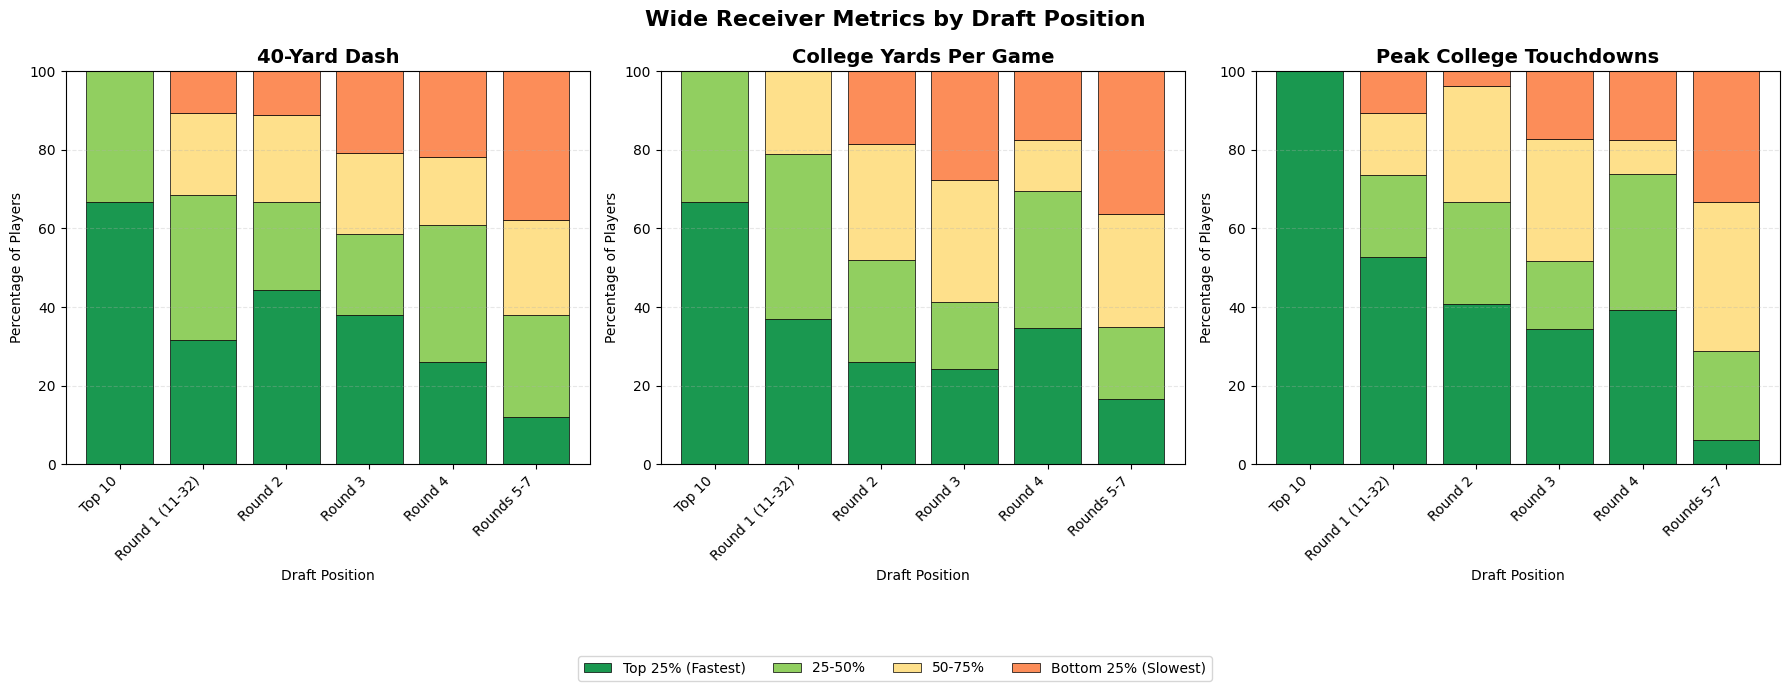


40-YARD DASH PERCENTAGES BY DRAFT POSITION
forty_tier       Top 25% (Fastest)  25-50%  50-75%  Bottom 25% (Slowest)
round_group                                                             
Top 10                        66.7    33.3     0.0                   0.0
Round 1 (11-32)               31.6    36.8    21.1                  10.5
Round 2                       44.4    22.2    22.2                  11.1
Round 3                       37.9    20.7    20.7                  20.7
Round 4                       26.1    34.8    17.4                  21.7
Rounds 5-7                    12.1    25.8    24.2                  37.9

COLLEGE YPG PERCENTAGES BY DRAFT POSITION
ypg_tier         Top 25%  25-50%  50-75%  Bottom 25%
round_group                                         
Top 10              66.7    33.3     0.0         0.0
Round 1 (11-32)     36.8    42.1    21.1         0.0
Round 2             25.9    25.9    29.6        18.5
Round 3             24.1    17.2    31.0        27.6
Round 4    

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# create round categories
def pick_category(row):
    if pd.isna(row['Pick']):
        return None
    if row['Pick'] <= 10:
        return 'Top 10'
    elif row['Round'] == 1:
        return 'Round 1 (11-32)'
    elif row['Round'] == 2:
        return 'Round 2'
    elif row['Round'] == 3:
        return 'Round 3'
    elif row['Round'] == 4:
        return 'Round 4'
    else:  # Rounds 5-7
        return 'Rounds 5-7'

# apply category
player_data['round_group'] = player_data.apply(pick_category, axis=1)


# 40-yard dash 
forty_fast = 4.40      # 25th percentile
forty_median = 4.46    # 50th percentile
forty_slow = 4.51      # 75th percentile

# College YPG 
ypg_high = 83.3        # 75th percentile
ypg_median = 68.2      # 50th percentile
ypg_low = 54.7         # 25th percentile

# Peak TDs 
td_high = 11.0         # 75th percentile
td_median = 9.0        # 50th percentile
td_low = 7.0           # 25th percentile

# tier columns
# 40-yard dash tiers
def forty_tier(time):
    if pd.isna(time):
        return None
    if time <= forty_fast:
        return 'Top 25% (Fastest)'
    elif time <= forty_median:
        return '25-50%'
    elif time <= forty_slow:
        return '50-75%'
    else:
        return 'Bottom 25% (Slowest)'

# YPG tiers
def ypg_tier(ypg):
    if pd.isna(ypg):
        return None
    if ypg >= ypg_high:
        return 'Top 25%'
    elif ypg >= ypg_median:
        return '25-50%'
    elif ypg >= ypg_low:
        return '50-75%'
    else:
        return 'Bottom 25%'

# TD tiers
def td_tier(td):
    if pd.isna(td):
        return None
    if td >= td_high:
        return 'Top 25%'
    elif td >= td_median:
        return '25-50%'
    elif td >= td_low:
        return '50-75%'
    else:
        return 'Bottom 25%'

# apply columns
player_data['forty_tier'] = player_data['forty_time'].apply(forty_tier)
player_data['ypg_tier'] = player_data['college_ypg'].apply(ypg_tier)
player_data['td_tier'] = player_data['peak_td'].apply(td_tier)

# percentage tables
forty_pct = pd.crosstab(
    index=player_data['round_group'],
    columns=player_data['forty_tier'],
    normalize='index'
) * 100

ypg_pct = pd.crosstab(
    index=player_data['round_group'],
    columns=player_data['ypg_tier'],
    normalize='index'
) * 100

td_pct = pd.crosstab(
    index=player_data['round_group'],
    columns=player_data['td_tier'],
    normalize='index'
) * 100

# Fill NaN
forty_pct = forty_pct.fillna(0)
ypg_pct = ypg_pct.fillna(0)
td_pct = td_pct.fillna(0)


# create side by side charts
# set up the figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Wide Receiver Metrics by Draft Position', fontsize=16, fontweight='bold')

# colors for tiers
colors = ['#1a9850', '#91cf60', '#fee08b', '#fc8d59']

# define the order for x-axis categories
category_order = ['Top 10', 'Round 1 (11-32)', 'Round 2', 'Round 3', 'Round 4', 'Rounds 5-7']

# chart 1: 40-Yard Dash
tier_order_forty = ['Top 25% (Fastest)', '25-50%', '50-75%', 'Bottom 25% (Slowest)']
# reindex to ensure correct category order
forty_pct = forty_pct.reindex(category_order)
# filter to existing columns
existing_cols = [col for col in tier_order_forty if col in forty_pct.columns]
forty_pct[existing_cols].plot(
    kind='bar', 
    stacked=True, 
    ax=axes[0], 
    color=colors[:len(existing_cols)],
    edgecolor='black',
    linewidth=0.5,
    width=0.8
)
axes[0].set_title('40-Yard Dash', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Draft Position')
axes[0].set_ylabel('Percentage of Players')
axes[0].set_ylim([0, 100])
axes[0].legend().remove()
axes[0].grid(True, alpha=0.3, linestyle='--', axis='y')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# chart 2: College YPG
tier_order_prod = ['Top 25%', '25-50%', '50-75%', 'Bottom 25%']
ypg_pct = ypg_pct.reindex(category_order)
existing_cols = [col for col in tier_order_prod if col in ypg_pct.columns]
ypg_pct[existing_cols].plot(
    kind='bar', 
    stacked=True, 
    ax=axes[1], 
    color=colors[:len(existing_cols)],
    edgecolor='black',
    linewidth=0.5,
    width=0.8
)
axes[1].set_title('College Yards Per Game', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Draft Position')
axes[1].set_ylabel('Percentage of Players')
axes[1].set_ylim([0, 100])
axes[1].legend().remove()
axes[1].grid(True, alpha=0.3, linestyle='--', axis='y')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

# chart 3: Peak TDs
td_pct = td_pct.reindex(category_order)
existing_cols = [col for col in tier_order_prod if col in td_pct.columns]
td_pct[existing_cols].plot(
    kind='bar', 
    stacked=True, 
    ax=axes[2], 
    color=colors[:len(existing_cols)],
    edgecolor='black',
    linewidth=0.5,
    width=0.8
)
axes[2].set_title('Peak College Touchdowns', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Draft Position')
axes[2].set_ylabel('Percentage of Players')
axes[2].set_ylim([0, 100])
axes[2].legend().remove()
axes[2].grid(True, alpha=0.3, linestyle='--', axis='y')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='right')

# add a single legend at the bottom
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.15))

plt.tight_layout()
plt.savefig('wr_metrics_by_draft_position.png', dpi=300, bbox_inches='tight')
plt.show()


# raw numbers
print("\n" + "=" * 60)
print("40-YARD DASH PERCENTAGES BY DRAFT POSITION")
print("=" * 60)
print(forty_pct[tier_order_forty].round(1).to_string())

print("\n" + "=" * 60)
print("COLLEGE YPG PERCENTAGES BY DRAFT POSITION")
print("=" * 60)
print(ypg_pct[tier_order_prod].round(1).to_string())

print("\n" + "=" * 60)
print("PEAK TD PERCENTAGES BY DRAFT POSITION")
print("=" * 60)
print(td_pct[tier_order_prod].round(1).to_string())

print("\n" + "=" * 60)
print("SAMPLE SIZES BY DRAFT POSITION")
print("=" * 60)
print(player_data['round_group'].value_counts().reindex(category_order))

### Key Takeaways: What Metrics Separate Draft Rounds

After visualizing how 40-yard dash time, college production, and touchdown totals distribute across draft capital, five clear patterns emerge:

**1. Round 4: The Production Sweet Spot**
Round 4 stands out as the draft's most interesting inflection point. While top-tier athletic testing (Top 25% 40 times) drops to just 26.1% in this round, elite production spikes back up—34.8% of Round 4 receivers were Top 25% in college YPG, nearly matching Round 1's 36.8% clip. Even more striking: 69.6% of Round 4 picks were Top 50% in YPG, actually *higher* than Round 1's 68.4%. This suggests Round 4 is where teams finally stop chasing athletic traits and scoop up productive college receivers who fell due to pedestrian combine numbers.

**2. The Speed Cliff Comes After Round 4**
Top 50% speed (4.46 or faster) is remarkably consistent from Round 1 through Round 4, hovering between 63-80% of selections. Then it collapses. In Rounds 5-7, only 37.9% of drafted receivers ran a sub-4.46 forty. This indicates that NFL teams have a hard floor on speed—if you're not at least league-average in straight-line athleticism, you're almost certainly lasting until Day 3.

**3. Early Rounds Prioritize Production Over Explosiveness**
Compare Round 1 (11-32) to Round 2:
- **40 times are nearly identical**—31.6% vs. 44.4% Top 25% speed (actually favors Round 2)
- **Production tells the real story**—36.8% of late-first picks were Top 25% in YPG vs. just 25.9% in Round 2
- **Touchdowns follow the same pattern**—52.6% Top 25% in Round 1 vs. 40.7% in Round 2

The difference between a late-first and early-second receiver isn't athleticism—it's proven college dominance.

**4. Bottom-Tier Metrics Create a Round 2 Ceiling**
If you're in the Bottom 25% of 40-yard dash (4.51+), peak TDs (6 or fewer), or college YPG (54.7 or less), you're almost unheard of in the first two rounds. Bottom 25% 40 times appear in just 10.5% of Round 1 and 11.1% of Round 2. Bottom 25% YPG? Zero in Round 1, 18.5% in Round 2—and those Round 2 exceptions are almost certainly the "athletic traits" guys who tested off the charts but didn't produce.

**5. Touchdowns Are the Ultimate Gatekeeper**
Peak college touchdowns show the most dramatic drop-off of any metric. Top 50% TD producers (9+ TDs) make up:
- **100%** of Top 10 picks
- **73.7%** of Round 1 (11-32)
- **66.6%** of Round 2
- **51.7%** of Round 3
- **73.9%** of Round 4 (!)
- **28.8%** of Rounds 5-7

The Round 4 spike (73.9% Top 50% in TDs) reinforces our first finding—this is where productive college scorers finally get selected, regardless of their 40 times. After that, the well runs dry.

**The Bottom Line:** Speed gets you in the building, but production—especially finding the end zone—determines how early you hear your name called. Round 4 emerges as the draft's great correction, where teams stop overvaluing traits and finally take the college producers who've been falling all along.

***
### Wrap-Up: What We Learned About Draft Drivers

This notebook set out to answer a simple question: if college production alone doesn't determine draft position (as we saw in Notebook 02), what does?

By combining college stats, combine athletic testing, and draft capital, we uncovered a clear hierarchy:

**1. Speed is the strongest single predictor of draft position.** The correlation analysis was unambiguous—40-yard dash time (r = 0.38) correlates more strongly with where a receiver gets drafted than any college production metric we measured. The visual is equally clear: faster players cluster at the top of the draft.

**2. Production still matters, but it's not the primary differentiator.** Peak college touchdowns (r = -0.36) and yards per game (r = -0.26) both correlate with draft position, but the relationship is weaker than for speed. The data suggests NFL teams use production to *confirm* a prospect's value, not to *establish* it.

**3. Conference pedigree provides a tangible boost.** While we simplified our final visualization to focus on metrics, our earlier exploratory analysis confirmed that SEC and Big Ten receivers are overrepresented in the first round—even when their production and speed metrics are comparable to prospects from other conferences.

**4. The "perfect profile" is a first-round lock.** When a receiver combines elite speed (sub-4.4), elite production (90+ YPG), and a Power Five conference pedigree, they are almost universally drafted within the first 32 picks. There are no bargains to be found here—the market prices this profile efficiently.

**The bottom line:** NFL teams prioritize traits they can't teach (speed) over production they hope will translate. College production gets you in the building, but speed determines how early you hear your name called.

***
### Looking Ahead

Now that we understand what *drives draft position*, the natural next question is: **what actually predicts NFL success?**

In Notebook 04, I'll flip the script. Instead of asking "what gets players drafted?", I'll ask "what makes them successful?" Using the tier classifications from Notebook 01 (Elite/Hit/Role/Bust), I'll analyze whether the same metrics that correlate with draft capital also correlate with professional production.

Specifically, I'll explore:
- Do elite NFL receivers share common athletic thresholds?
- Is college production or combine testing more predictive of pro success?
- Can we identify "bust" warning signs before the draft?

This analysis will tie together everything we've learned—draft capital, college production, athletic testing, and conference pedigree—to build a complete picture of what separates NFL stars from busts.

***
## LINKS <br>
#### [PORTFOLIO](https://quinng8.github.io/nfl-draft-analytics/)
#### [Predictive NFL Success](https://quinng8.github.io/nfl-draft-analytics/04_predictive_NFL_success.html)